# RQ3: Nightmare language predicting PHQ-9 / GAD-7 by Country

Analyze USA and Argentina separately using off‑the‑shelf sentiment tools.
Predictors: VADER sentiment, TextBlob sentiment, optional embedding-based nightmare intensity.
Outcomes: `phq_total`, `gad_total`.

## 0. Setup
Install if needed:
```bash
pip install pandas scikit-learn nltk textblob sentence-transformers
```

In [6]:
import re
from pathlib import Path
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LassoCV
from sklearn.metrics import r2_score, mean_absolute_error

import nltk
from nltk.sentiment import SentimentIntensityAnalyzer
from textblob import TextBlob

try:
    from sentence_transformers import SentenceTransformer

    EMBEDDING_AVAILABLE = True
except Exception:
    SentenceTransformer = None
    EMBEDDING_AVAILABLE = False

try:
    nltk.data.find("sentiment/vader_lexicon.zip")
except LookupError:
    nltk.download("vader_lexicon")

pd.set_option("display.max_colwidth", 140)
DATA_PATH = Path("Upd Integration") / "10 Feb Updates" / "integrated_dream_data_v0.csv"

## 1. Common cleaning
- Drop very short or placeholder dreams
- Coerce outcomes to numeric

In [7]:
raw = pd.read_csv(DATA_PATH)
print("raw shape", raw.shape)

raw["dream_text"] = raw["dream_text"].astype(str).str.strip()
raw = raw[raw["dream_text"].str.len() >= 20].copy()
placeholders = [
    "no dreams",
    "no dream",
    "dont remember",
    "do not remember",
    "cannot remember",
    "cant remember",
    "none that i remember",
]
mask_placeholder = (
    raw["dream_text"].str.lower().apply(lambda t: any(p in t for p in placeholders))
)
raw = raw[~mask_placeholder].copy()

raw["phq_total"] = pd.to_numeric(raw.get("phq_total"), errors="coerce")
raw["gad_total"] = pd.to_numeric(raw.get("gad_total"), errors="coerce")
raw = raw.dropna(subset=["phq_total", "gad_total", "country"])
print("after filters", raw.shape)
raw[["country", "dream_text"]].head()

raw shape (9841, 24)
after filters (9684, 24)


,country,dream_text
1,USA,I don't remember dreams
2,USA,"I had a dream that my old cats were still alive. They were getting old and had cat Alzheimer's in my dream, but they were all alive and ..."
3,USA,I dreamt I encountered someone from my past. We embraced and I felt joy at reconnecting
4,USA,I had a couple nightmare dreams
6,USA,Don't remember any dreams.


## 2. Nightmare Rate
For each country subset:
- VADER: compound/pos/neg/neu
- TextBlob: polarity/subjectivity
- Nightmare intensity: Sentence-BERT similarity to fear anchors; fallback = VADER neg

In [8]:
df_us = raw[raw["country"] == "USA"].copy()

In [9]:
from empath import Empath
import numpy as np

lexicon = Empath()

nightmare_categories = [
    "fear",
    "violence",
    "death",
    "negative_emotion",
    "crime",
    "injury",
]


def empath_nightmare_rate(text: str) -> float:
    if not isinstance(text, str) or len(text.strip()) == 0:
        return 0.0
    scores = lexicon.analyze(text, categories=nightmare_categories, normalize=True)
    return float(sum(scores.values()) * 100)


df_us["nightmare_content_rate"] = df_us["dream_text"].apply(empath_nightmare_rate)

# Zero-inflation handling (important)
df_us["nightmare_any"] = (df_us["nightmare_content_rate"] > 0).astype(int)
df_us["nightmare_content_log"] = np.log1p(df_us["nightmare_content_rate"])

In [10]:
df_us[
    ["dream_text", "nightmare_content_rate", "nightmare_any", "nightmare_content_log"]
].head()

,dream_text,nightmare_content_rate,nightmare_any,nightmare_content_log
1,I don't remember dreams,0.0,0,0.0
2,"I had a dream that my old cats were still alive. They were getting old and had cat Alzheimer's in my dream, but they were all alive and ...",0.0,0,0.0
3,I dreamt I encountered someone from my past. We embraced and I felt joy at reconnecting,0.0,0,0.0
4,I had a couple nightmare dreams,0.0,0,0.0
6,Don't remember any dreams.,0.0,0,0.0


In [11]:
df_us[["nightmare_content_rate"]].describe()

,nightmare_content_rate
count,1858.000000
mean,1.893803
std,4.221289
min,0.000000
25%,0.000000
50%,0.000000
75%,2.414677
max,44.444444


## 3. Train/test split and modeling helper

In [12]:
import sys

print("Python:", sys.version)
print("Executable:", sys.executable)

try:
    import tiktoken

    print("tiktoken OK:", tiktoken.__version__)
except Exception as e:
    print("tiktoken NOT available:", repr(e))

Python: 3.12.6 | packaged by conda-forge | (main, Sep 11 2024, 04:55:15) [Clang 17.0.6 ]
Executable: /opt/miniconda3/bin/python
tiktoken OK: 0.12.0


In [13]:
import os, numpy as np
from transformers import pipeline

os.environ["TOKENIZERS_PARALLELISM"] = "false"

labels = ["fear", "threat", "danger", "violence", "distress"]

zsc = pipeline(
    "zero-shot-classification",
    model="MoritzLaurer/mDeBERTa-v3-base-mnli-xnli",
    device=-1,
)

In [14]:
import numpy as np

labels = ["fear", "threat", "danger", "violence", "distress"]

texts = df_us["dream_text"].fillna("").astype(str).tolist()

outs = zsc(texts, candidate_labels=labels, multi_label=True, batch_size=16)

df_us["nightmare_intensity"] = [float(np.mean(o["scores"])) for o in outs]

In [15]:
df_us["nightmare_intensity"].describe()

count    1858.000000
mean        0.445119
std         0.278976
min         0.000740
25%         0.200709
50%         0.439488
75%         0.688634
max         0.994326
Name: nightmare_intensity, dtype: float64

In [16]:
df_us[["nightmare_content_rate", "nightmare_intensity"]].corr()

,nightmare_content_rate,nightmare_intensity
nightmare_content_rate,1.000000,0.226749
nightmare_intensity,0.226749,1.000000


In [17]:
from nltk.sentiment import SentimentIntensityAnalyzer

# Initialize VADER
sia = SentimentIntensityAnalyzer()


def get_vader_scores(text):
    if pd.isna(text) or text == "":
        return 0.0, 0.0
    scores = sia.polarity_scores(str(text))
    return scores["compound"], scores["neg"]


# Apply to df_us
df_us[["vader_compound", "vader_neg"]] = df_us["dream_text"].apply(
    lambda x: pd.Series(get_vader_scores(x))
)

print("VADER scores added to df_us.")
print(df_us[["dream_text", "vader_compound", "nightmare_intensity"]].head())

VADER scores added to df_us.
                                                                                                                                    dream_text  \
1                                                                                                                      I don't remember dreams   
2  I had a dream that my old cats were still alive. They were getting old and had cat Alzheimer's in my dream, but they were all alive and ...   
3                                                      I dreamt I encountered someone from my past. We embraced and I felt joy at reconnecting   
4                                                                                                              I had a couple nightmare dreams   
6                                                                                                                   Don't remember any dreams.   

   vader_compound  nightmare_intensity  
1         -0.3089             0.764239  
2          0

## 4. Run per country

In [18]:
import statsmodels.api as sm
from sklearn.preprocessing import StandardScaler

# 1. Prepare data and drop NaNs
# Note: Ensure these columns exist in df_us
predictors = ["nightmare_intensity", "nightmare_content_log", "vader_compound"]
df_analysis = df_us.dropna(subset=predictors + ["phq_total", "gad_total"]).copy()

# 2. Scale predictors (Crucial for comparing coefficients)
scaler = StandardScaler()
df_analysis[predictors] = scaler.fit_transform(df_analysis[predictors])


def run_stable_rq3(target):
    print(f"\n{'='*20} Results for {target.upper()} {'='*20}")

    # Add a constant (intercept) - OLS needs this explicitly in statsmodels
    X = sm.add_constant(df_analysis[predictors])
    y = df_analysis[target]

    # Fit OLS model with Robust Standard Errors ('HC3' is standard for small/medium samples)
    model = sm.OLS(y, X).fit(cov_type="HC3")

    print(model.summary())
    return model


# Run for both
phq_res = run_stable_rq3("phq_total")
gad_res = run_stable_rq3("gad_total")


==================== Results for PHQ_TOTAL ====================
                            OLS Regression Results                            
Dep. Variable:              phq_total   R-squared:                       0.016
Model:                            OLS   Adj. R-squared:                  0.014
Method:                 Least Squares   F-statistic:                     9.677
Date:                Mon, 23 Feb 2026   Prob (F-statistic):           2.45e-06
Time:                        18:05:59   Log-Likelihood:                -5900.5
No. Observations:                1858   AIC:                         1.181e+04
Df Residuals:                    1854   BIC:                         1.183e+04
Df Model:                           3                                         
Covariance Type:                  HC3                                         
                            coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------

In [19]:
import statsmodels.formula.api as smf

analysis_df = df_us.dropna(
    subset=[
        "phq_total",
        "nightmare_intensity",
        "nightmare_content_log",
        "vader_compound",
        "participant_id",
    ]
).copy()

analysis_df["participant_id"] = analysis_df["participant_id"].astype(str)

model_phq = smf.mixedlm(
    "phq_total ~ nightmare_intensity + nightmare_content_log + vader_compound",
    analysis_df,
    groups=analysis_df["participant_id"],
).fit(reml=False)

print(model_phq.summary())

             Mixed Linear Model Regression Results
Model:                MixedLM   Dependent Variable:   phq_total 
No. Observations:     1856      Method:               ML        
No. Groups:           542       Scale:                5.1042    
Min. group size:      1         Log-Likelihood:       -4936.9026
Max. group size:      5         Converged:            Yes       
Mean group size:      3.4                                       
----------------------------------------------------------------
                      Coef.  Std.Err.   z    P>|z| [0.025 0.975]
----------------------------------------------------------------
Intercept              5.976    0.276 21.633 0.000  5.435  6.518
nightmare_intensity    0.120    0.275  0.437 0.662 -0.420  0.660
nightmare_content_log  0.146    0.077  1.891 0.059 -0.005  0.298
vader_compound        -0.157    0.151 -1.033 0.301 -0.453  0.140
Group Var             29.735    1.019                           



In [20]:
import statsmodels.formula.api as smf

analysis_df = df_us.dropna(
    subset=[
        "phq_total",
        "nightmare_intensity",
        "nightmare_content_log",
        "vader_compound",
        "participant_id",
    ]
).copy()

analysis_df["participant_id"] = analysis_df["participant_id"].astype(str)

model_gad = smf.mixedlm(
    "gad_total ~ nightmare_intensity + nightmare_content_log + vader_compound",
    analysis_df,
    groups=analysis_df["participant_id"],
).fit(reml=False)

print(model_gad.summary())

             Mixed Linear Model Regression Results
Model:                MixedLM   Dependent Variable:   gad_total 
No. Observations:     1856      Method:               ML        
No. Groups:           542       Scale:                3.9280    
Min. group size:      1         Log-Likelihood:       -4674.8726
Max. group size:      5         Converged:            Yes       
Mean group size:      3.4                                       
----------------------------------------------------------------
                      Coef.  Std.Err.   z    P>|z| [0.025 0.975]
----------------------------------------------------------------
Intercept              4.867    0.236 20.636 0.000  4.405  5.329
nightmare_intensity    0.528    0.241  2.188 0.029  0.055  1.000
nightmare_content_log  0.081    0.068  1.201 0.230 -0.052  0.214
vader_compound         0.008    0.133  0.060 0.952 -0.252  0.268
Group Var             21.232    0.834                           



### RQ4: Country Moderation (USA vs Argentina)

In [21]:
raw.head()

,source_file,country,language,timepoint,participant_id,dream_text,dream_feelings,dream_talk,dream_write,dream_content,...,dream_intensity,gad_total,phq_total,age,education,student,gender,sleep_quality,sleep_hours,sleep_disturbed
1,"Dream Follow Up 1_April 14, 2024_22.21.csv",USA,English,2,63386e75b02c4d7013c1198b,I don't remember dreams,NaN,No,No,No,...,Not at all intense,7.0,13.0,55-64,Some college,Yes,Non-binary / third gender,Fairly bad,5.0,Multiple times a night
2,"Dream Follow Up 1_April 14, 2024_22.21.csv",USA,English,2,6090578fb2299eacaec32b7a,"I had a dream that my old cats were still alive. They were getting old and had cat Alzheimer's in my dream, but they were all alive and ...",Average,Yes,No,No,...,Not that intense,9.0,17.0,25-34,High school graduate,No,Female,Fairly good,8.0,Once a week
3,"Dream Follow Up 1_April 14, 2024_22.21.csv",USA,English,2,58d876b14240e50001190090,I dreamt I encountered someone from my past. We embraced and I felt joy at reconnecting,Average,No,Yes,No,...,Somewhat intense,14.0,13.0,45-54,Doctorate,No,Male,Fairly bad,6.0,2-3 nights a week
4,"Dream Follow Up 1_April 14, 2024_22.21.csv",USA,English,2,655a395e2828d333bae0ea4b,I had a couple nightmare dreams,Average,No,No,No,...,Not that intense,9.0,9.0,55-64,High school graduate,No,Male,Fairly good,8.0,Once a week
6,"Dream Follow Up 1_April 14, 2024_22.21.csv",USA,English,2,659daa1ed4e13d6428103c1f,Don't remember any dreams.,NaN,No,No,Yes,...,Not that intense,0.0,0.0,55-64,4 year degree,No,Female,Fairly good,7.0,Once a night


In [22]:
df_ar = raw[(raw["country"] == "Argentina") & (raw["language"] == "English")].copy()

In [23]:
from empath import Empath
import numpy as np

lexicon = Empath()

nightmare_categories = [
    "fear",
    "violence",
    "death",
    "negative_emotion",
    "crime",
    "injury",
]


def empath_nightmare_rate(text: str) -> float:
    if not isinstance(text, str) or len(text.strip()) == 0:
        return 0.0
    scores = lexicon.analyze(text, categories=nightmare_categories, normalize=True)
    return float(sum(scores.values()) * 100)


df_ar["nightmare_content_rate"] = df_ar["dream_text"].apply(empath_nightmare_rate)

# Zero-inflation handling (important)
df_ar["nightmare_any"] = (df_ar["nightmare_content_rate"] > 0).astype(int)
df_ar["nightmare_content_log"] = np.log1p(df_ar["nightmare_content_rate"])

In [24]:
df_ar[
    ["dream_text", "nightmare_content_rate", "nightmare_any", "nightmare_content_log"]
].head()

,dream_text,nightmare_content_rate,nightmare_any,nightmare_content_log
1982,"I have a dream that is repeated very often, I mean once or twice a month, and in the dream it happens to me that I am with several peopl...",2.857143,1,1.349927
1983,"I dreamed about the mother of the child I provide therapeutic support to and some debts, but I don't remember the specific content, but ...",3.448276,1,1.492517
1984,Two dreams: the first one about moving and the second about traveling / going to a concert.,0.000000,0,0.000000
1985,I dreamed that we found out that my son's father had died.,0.000000,0,0.000000
1986,"I dream a few days with ""Valorant"" a game of shooters that I play, but the characters are known people",0.000000,0,0.000000


In [25]:
import numpy as np

labels = ["fear", "threat", "danger", "violence", "distress"]

texts = df_ar["dream_text"].fillna("").astype(str).tolist()

outs = zsc(texts, candidate_labels=labels, multi_label=True, batch_size=16)

df_ar["nightmare_intensity"] = [float(np.mean(o["scores"])) for o in outs]

In [26]:
df_ar["nightmare_intensity"].describe()

count    3916.000000
mean        0.507339
std         0.276136
min         0.000252
25%         0.274445
50%         0.533386
75%         0.741847
max         0.991246
Name: nightmare_intensity, dtype: float64

In [27]:
df_ar[["nightmare_content_rate"]].describe()

,nightmare_content_rate
count,3916.000000
mean,2.494660
std,5.631426
min,0.000000
25%,0.000000
50%,0.000000
75%,2.941176
max,100.000000


In [28]:
df_ar[["nightmare_content_rate", "nightmare_intensity"]].corr()

,nightmare_content_rate,nightmare_intensity
nightmare_content_rate,1.00000,0.24515
nightmare_intensity,0.24515,1.00000


In [29]:
from nltk.sentiment import SentimentIntensityAnalyzer

# Initialize VADER
sia = SentimentIntensityAnalyzer()


def get_vader_scores(text):
    if pd.isna(text) or text == "":
        return 0.0, 0.0
    scores = sia.polarity_scores(str(text))
    return scores["compound"], scores["neg"]


# Apply to df_ar
df_ar[["vader_compound", "vader_neg"]] = df_ar["dream_text"].apply(
    lambda x: pd.Series(get_vader_scores(x))
)

print("VADER scores added to df_ar.")
print(df_ar[["dream_text", "vader_compound", "nightmare_intensity"]].head())

VADER scores added to df_ar.
                                                                                                                                       dream_text  \
1982  I have a dream that is repeated very often, I mean once or twice a month, and in the dream it happens to me that I am with several peopl...   
1983  I dreamed about the mother of the child I provide therapeutic support to and some debts, but I don't remember the specific content, but ...   
1984                                                  Two dreams: the first one about moving and the second about traveling / going to a concert.   
1985                                                                                   I dreamed that we found out that my son's father had died.   
1986                                       I dream a few days with "Valorant" a game of shooters that I play, but the characters are known people   

      vader_compound  nightmare_intensity  
1982          0.3182            

In [30]:
import statsmodels.api as sm
from sklearn.preprocessing import StandardScaler

# 1. Prepare data and drop NaNs
# Note: Ensure these columns exist in df_us
predictors = ["nightmare_intensity", "nightmare_content_log", "vader_compound"]
df_analysis_ar = df_ar.dropna(subset=predictors + ["phq_total", "gad_total"]).copy()

# 2. Scale predictors (Crucial for comparing coefficients)
scaler = StandardScaler()
df_analysis_ar[predictors] = scaler.fit_transform(df_analysis_ar[predictors])


def run_stable_rq3(target):
    print(f"\n{'='*20} Results for {target.upper()} {'='*20}")

    # Add a constant (intercept) - OLS needs this explicitly in statsmodels
    X = sm.add_constant(df_analysis_ar[predictors])
    y = df_analysis_ar[target]

    # Fit OLS model with Robust Standard Errors ('HC3' is standard for small/medium samples)
    model = sm.OLS(y, X).fit(cov_type="HC3")

    print(model.summary())
    return model


# Run for both
phq_res = run_stable_rq3("phq_total")
gad_res = run_stable_rq3("gad_total")


==================== Results for PHQ_TOTAL ====================
                            OLS Regression Results                            
Dep. Variable:              phq_total   R-squared:                       0.012
Model:                            OLS   Adj. R-squared:                  0.011
Method:                 Least Squares   F-statistic:                     15.93
Date:                Mon, 23 Feb 2026   Prob (F-statistic):           2.71e-10
Time:                        18:44:53   Log-Likelihood:                -12182.
No. Observations:                3916   AIC:                         2.437e+04
Df Residuals:                    3912   BIC:                         2.440e+04
Df Model:                           3                                         
Covariance Type:                  HC3                                         
                            coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------

In [31]:
import statsmodels.formula.api as smf

analysis_df_ar = df_ar.dropna(
    subset=[
        "phq_total",
        "nightmare_intensity",
        "nightmare_content_log",
        "vader_compound",
        "participant_id",
    ]
).copy()

analysis_df_ar["participant_id"] = analysis_df_ar["participant_id"].astype(str)

model_phq = smf.mixedlm(
    "phq_total ~ nightmare_intensity + nightmare_content_log + vader_compound",
    analysis_df_ar,
    groups=analysis_df_ar["participant_id"],
).fit(reml=False)

print(model_phq.summary())

             Mixed Linear Model Regression Results
Model:               MixedLM   Dependent Variable:   phq_total  
No. Observations:    3916      Method:               ML         
No. Groups:          1152      Scale:                9.6355     
Min. group size:     1         Log-Likelihood:       -11132.3766
Max. group size:     8         Converged:            Yes        
Mean group size:     3.4                                        
----------------------------------------------------------------
                      Coef.  Std.Err.   z    P>|z| [0.025 0.975]
----------------------------------------------------------------
Intercept              7.838    0.189 41.370 0.000  7.466  8.209
nightmare_intensity    0.684    0.247  2.774 0.006  0.201  1.167
nightmare_content_log  0.004    0.069  0.059 0.953 -0.132  0.140
vader_compound        -0.067    0.124 -0.538 0.591 -0.311  0.177
Group Var             19.823    0.373                           



In [32]:
import statsmodels.formula.api as smf

analysis_df_ar = df_ar.dropna(
    subset=[
        "phq_total",
        "nightmare_intensity",
        "nightmare_content_log",
        "vader_compound",
        "participant_id",
    ]
).copy()

analysis_df_ar["participant_id"] = analysis_df_ar["participant_id"].astype(str)

model_gad = smf.mixedlm(
    "gad_total ~ nightmare_intensity + nightmare_content_log + vader_compound",
    analysis_df_ar,
    groups=analysis_df_ar["participant_id"],
).fit(reml=False)

print(model_gad.summary())

             Mixed Linear Model Regression Results
Model:               MixedLM   Dependent Variable:   gad_total  
No. Observations:    3916      Method:               ML         
No. Groups:          1152      Scale:                9.0682     
Min. group size:     1         Log-Likelihood:       -10865.0895
Max. group size:     8         Converged:            Yes        
Mean group size:     3.4                                        
----------------------------------------------------------------
                      Coef.  Std.Err.   z    P>|z| [0.025 0.975]
----------------------------------------------------------------
Intercept              7.048    0.171 41.321 0.000  6.714  7.383
nightmare_intensity    0.573    0.237  2.419 0.016  0.109  1.037
nightmare_content_log  0.079    0.067  1.186 0.236 -0.051  0.209
vader_compound        -0.257    0.120 -2.146 0.032 -0.491 -0.022
Group Var             13.637    0.276                           



# RQ4: Do associations between nightmare-related linguistic markers and mental health symptoms differ by country (U.S. vs. Argentina)?


In [35]:
df_rq4 = pd.concat([df_us, df_ar], ignore_index=True)

# sanity check
print(df_rq4.columns[df_rq4.columns.str.contains("nightmare|vader", case=False)])
print(
    df_rq4[
        [
            "country",
            "participant_id",
            "nightmare_intensity",
            "nightmare_content_log",
            "vader_compound",
        ]
    ].head()
)

Index(['nightmare_content_rate', 'nightmare_any', 'nightmare_content_log',
       'nightmare_intensity', 'vader_compound', 'vader_neg'],
      dtype='object')
  country            participant_id  nightmare_intensity  \
0     USA  63386e75b02c4d7013c1198b             0.764239   
1     USA  6090578fb2299eacaec32b7a             0.058816   
2     USA  58d876b14240e50001190090             0.002256   
3     USA  655a395e2828d333bae0ea4b             0.818306   
4     USA  659daa1ed4e13d6428103c1f             0.890093   

   nightmare_content_log  vader_compound  
0                    0.0         -0.3089  
1                    0.0          0.9295  
2                    0.0          0.5859  
3                    0.0          0.4019  
4                    0.0         -0.3089  


In [36]:
# Ensure numeric
for col in [
    "phq_total",
    "gad_total",
    "nightmare_intensity",
    "nightmare_content_log",
    "vader_compound",
]:
    df_rq4[col] = pd.to_numeric(df_rq4[col], errors="coerce")

# Drop missing
df_rq4 = df_rq4.dropna(
    subset=[
        "participant_id",
        "country",
        "phq_total",
        "gad_total",
        "nightmare_intensity",
        "nightmare_content_log",
        "vader_compound",
    ]
).copy()

print("RQ4 N:", len(df_rq4))
print(df_rq4["country"].value_counts())

# ---------
# 2) Standardize predictors (important for interaction)
# ---------

scaler = StandardScaler()
df_rq4[["nightmare_intensity", "nightmare_content_log", "vader_compound"]] = (
    scaler.fit_transform(
        df_rq4[["nightmare_intensity", "nightmare_content_log", "vader_compound"]]
    )
)

# Set country reference to USA
df_rq4["country"] = df_rq4["country"].astype("category")
df_rq4["country"] = df_rq4["country"].cat.reorder_categories(
    ["USA", "Argentina"], ordered=True
)

# ---------
# 3) Interaction formulas
# ---------

formula_phq = """
phq_total ~
nightmare_intensity * C(country) +
nightmare_content_log * C(country) +
vader_compound
"""

formula_gad = """
gad_total ~
nightmare_intensity * C(country) +
nightmare_content_log * C(country) +
vader_compound
"""

# ---------
# 4) Fit Mixed Models (random intercept per participant)
# ---------

m_phq_rq4 = smf.mixedlm(formula_phq, df_rq4, groups=df_rq4["participant_id"]).fit(
    reml=False
)

m_gad_rq4 = smf.mixedlm(formula_gad, df_rq4, groups=df_rq4["participant_id"]).fit(
    reml=False
)

print("\n========== RQ4 PHQ ==========")
print(m_phq_rq4.summary())

print("\n========== RQ4 GAD ==========")
print(m_gad_rq4.summary())

RQ4 N: 5772
country
Argentina    3916
USA          1856
Name: count, dtype: int64

========== RQ4 PHQ ==========
                         Mixed Linear Model Regression Results
Model:                       MixedLM           Dependent Variable:           phq_total  
No. Observations:            5772              Method:                       ML         
No. Groups:                  1694              Scale:                        8.1811     
Min. group size:             1                 Log-Likelihood:               -16159.9636
Max. group size:             8                 Converged:                    Yes        
Mean group size:             3.4                                                        
----------------------------------------------------------------------------------------
                                              Coef.  Std.Err.   z    P>|z| [0.025 0.975]
----------------------------------------------------------------------------------------
Intercept              

# Strengthen PHQ/GAD Exploratory Data Analysis

In [37]:
eda_table = (
    df_rq4.groupby(["country", "timepoint"])
    .agg(
        PHQ_mean=("phq_total", "mean"),
        PHQ_sd=("phq_total", "std"),
        GAD_mean=("gad_total", "mean"),
        GAD_sd=("gad_total", "std"),
        N=("phq_total", "count"),
    )
    .reset_index()
)

eda_table

/var/folders/gj/nvvqk8_x3l56pvm3zf2l8g_r0000gn/T/ipykernel_27338/4213866550.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_rq4.groupby(["country", "timepoint"])


,country,timepoint,PHQ_mean,PHQ_sd,GAD_mean,GAD_sd,N
0,USA,1,6.504184,6.111043,5.638075,5.227806,478
1,USA,2,6.146835,5.900504,5.040506,4.793543,395
2,USA,3,5.641243,5.635138,4.836158,4.921623,354
3,USA,4,5.800000,5.891509,4.747692,4.920764,325
4,USA,5,5.371711,5.457002,4.440789,4.726491,304
5,Argentina,1,8.657390,5.569807,7.856046,4.695984,1042
6,Argentina,2,8.233179,5.297221,7.544084,4.797868,862
7,Argentina,3,8.144399,5.521891,7.342780,4.937574,741
8,Argentina,4,7.748476,5.451731,6.868902,4.841413,656
9,Argentina,5,7.770732,5.395841,6.926829,4.771609,615


In [38]:
import statsmodels.formula.api as smf

anova_phq = smf.mixedlm(
    "phq_total ~ C(country) * C(timepoint)", df_rq4, groups=df_rq4["participant_id"]
).fit()

print(anova_phq.summary())

                       Mixed Linear Model Regression Results
Model:                     MixedLM          Dependent Variable:          phq_total  
No. Observations:          5772             Method:                      REML       
No. Groups:                1694             Scale:                       8.0980     
Min. group size:           1                Log-Likelihood:              -16146.9864
Max. group size:           8                Converged:                   Yes        
Mean group size:           3.4                                                      
------------------------------------------------------------------------------------
                                          Coef.  Std.Err.   z    P>|z| [0.025 0.975]
------------------------------------------------------------------------------------
Intercept                                  6.460    0.246 26.282 0.000  5.978  6.941
C(country)[T.Argentina]                    2.135    0.298  7.174 0.000  1.552  2.719
C(ti

/var/folders/gj/nvvqk8_x3l56pvm3zf2l8g_r0000gn/T/ipykernel_27338/1017487875.py:11: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=('ci', 95)` for the same effect.

  sns.lineplot(


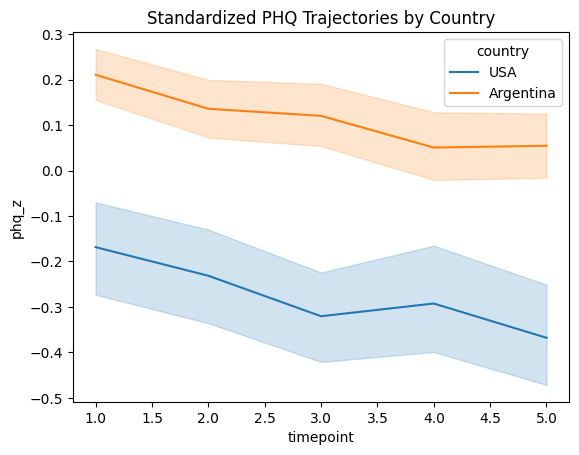

In [39]:
from sklearn.preprocessing import StandardScaler
import seaborn as sns
import matplotlib.pyplot as plt

df_plot = df_rq4.copy()

scaler = StandardScaler()
df_plot["phq_z"] = scaler.fit_transform(df_plot[["phq_total"]])
df_plot["gad_z"] = scaler.fit_transform(df_plot[["gad_total"]])

sns.lineplot(
    data=df_plot, x="timepoint", y="phq_z", hue="country", estimator="mean", ci=95
)
plt.title("Standardized PHQ Trajectories by Country")
plt.show()

/var/folders/gj/nvvqk8_x3l56pvm3zf2l8g_r0000gn/T/ipykernel_27338/3359592742.py:1: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=('ci', 95)` for the same effect.

  sns.lineplot(


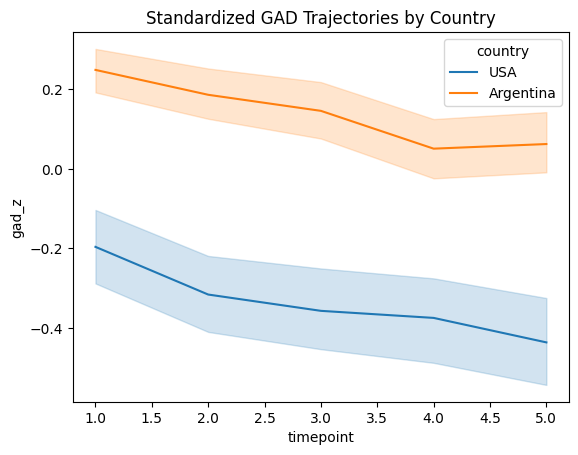

In [48]:
sns.lineplot(
    data=df_plot, x="timepoint", y="gad_z", hue="country", estimator="mean", ci=95
)
plt.title("Standardized GAD Trajectories by Country")
plt.show()

# Test Attrition Hypothesis

In [41]:
df_rq4.groupby(["country", "timepoint"])["participant_id"].nunique()

/var/folders/gj/nvvqk8_x3l56pvm3zf2l8g_r0000gn/T/ipykernel_27338/1299383881.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_rq4.groupby(["country", "timepoint"])["participant_id"].nunique()


country    timepoint
USA        1             478
           2             394
           3             354
           4             325
           5             304
Argentina  1            1042
           2             862
           3             740
           4             656
           5             612
Name: participant_id, dtype: int64

In [42]:
max_time = df_rq4["timepoint"].max()

completion_status = df_rq4.groupby("participant_id")["timepoint"].max().reset_index()

completion_status["completed"] = completion_status["timepoint"] == max_time

In [43]:
df_attrition = df_rq4.merge(
    completion_status[["participant_id", "completed"]], on="participant_id"
)

In [44]:
baseline = df_attrition[df_attrition["timepoint"] == 1]

import scipy.stats as stats

stats.ttest_ind(
    baseline[baseline["completed"]]["phq_total"],
    baseline[~baseline["completed"]]["phq_total"],
    equal_var=False,
)

TtestResult(statistic=np.float64(-0.7221066266024851), pvalue=np.float64(0.47034393563311183), df=np.float64(1467.9425628901774))

In [49]:
stats.ttest_ind(
    baseline[baseline["completed"]]["gad_total"],
    baseline[~baseline["completed"]]["gad_total"],
    equal_var=False,
)

TtestResult(statistic=np.float64(-0.12344558137915004), pvalue=np.float64(0.901771069136621), df=np.float64(1476.1977150993048))

### Longitudinal Individual Change

In [45]:
df_sorted = df_rq4.sort_values(["participant_id", "timepoint"])

df_sorted["phq_change"] = df_sorted.groupby("participant_id")["phq_total"].diff()

df_sorted["gad_change"] = df_sorted.groupby("participant_id")["gad_total"].diff()

In [46]:
delta_summary = df_sorted.groupby("participant_id").agg(
    avg_delta_phq=("phq_change", "mean"), avg_delta_gad=("gad_change", "mean")
)

delta_summary.describe()

,avg_delta_phq,avg_delta_gad
count,1397.000000,1397.000000
mean,-0.290717,-0.324317
std,2.171917,1.981987
min,-19.000000,-16.000000
25%,-1.000000,-1.000000
50%,0.000000,-0.250000
75%,0.500000,0.500000
max,10.000000,11.000000


In [47]:
time_model_phq = smf.mixedlm(
    "phq_total ~ timepoint", df_rq4, groups=df_rq4["participant_id"]
).fit()

print(time_model_phq.summary())

          Mixed Linear Model Regression Results
Model:            MixedLM Dependent Variable: phq_total  
No. Observations: 5772    Method:             REML       
No. Groups:       1694    Scale:              8.0929     
Min. group size:  1       Log-Likelihood:     -16174.9018
Max. group size:  8       Converged:          Yes        
Mean group size:  3.4                                    
----------------------------------------------------------
           Coef.   Std.Err.    z     P>|z|  [0.025  0.975]
----------------------------------------------------------
Intercept   8.059     0.146  55.301  0.000   7.774   8.345
timepoint  -0.216     0.029  -7.552  0.000  -0.272  -0.160
Group Var  24.051     0.390                               



In [50]:
time_model_gad = smf.mixedlm(
    "gad_total ~ timepoint", df_rq4, groups=df_rq4["participant_id"]
).fit()

print(time_model_gad.summary())

          Mixed Linear Model Regression Results
Model:            MixedLM Dependent Variable: gad_total  
No. Observations: 5772    Method:             REML       
No. Groups:       1694    Scale:              7.3092     
Min. group size:  1       Log-Likelihood:     -15713.4485
Max. group size:  8       Converged:          Yes        
Mean group size:  3.4                                    
----------------------------------------------------------
           Coef.   Std.Err.    z     P>|z|  [0.025  0.975]
----------------------------------------------------------
Intercept   7.291     0.129  56.649  0.000   7.039   7.543
timepoint  -0.245     0.027  -9.048  0.000  -0.298  -0.192
Group Var  17.312     0.302                               



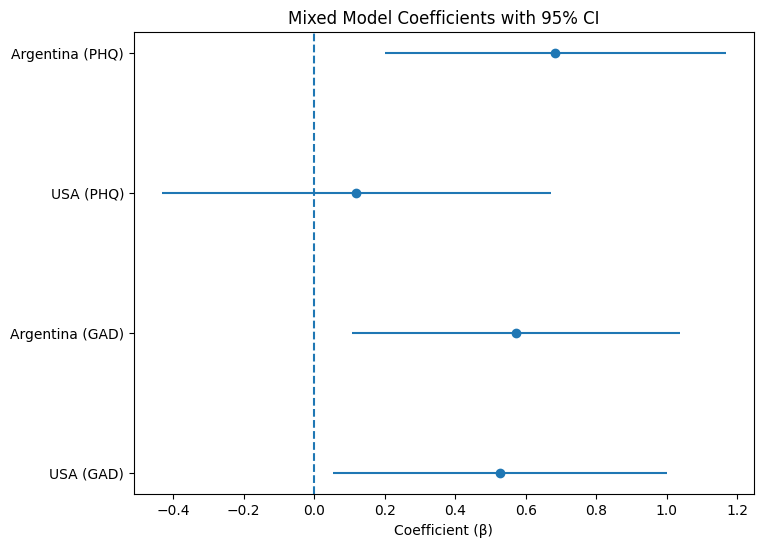

In [55]:
coef_df = pd.DataFrame(
    {
        "Country": ["USA (GAD)", "Argentina (GAD)", "USA (PHQ)", "Argentina (PHQ)"],
        "Beta": [0.528, 0.573, 0.120, 0.684],
        "Lower": [0.055, 0.109, -0.431, 0.201],
        "Upper": [1.000, 1.037, 0.671, 1.167],
    }
)

plt.figure(figsize=(8, 6))
plt.errorbar(
    coef_df["Beta"],
    coef_df["Country"],
    xerr=[coef_df["Beta"] - coef_df["Lower"], coef_df["Upper"] - coef_df["Beta"]],
    fmt="o",
)

plt.axvline(0, linestyle="--")
plt.title("Mixed Model Coefficients with 95% CI")
plt.xlabel("Coefficient (β)")
plt.show()